In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

In [9]:
# Positivo
JModesP = np.load("stability_lambda_n_case/Multifrequency/data_JModes_P.npy", allow_pickle=True)
JVectP = np.load("stability_lambda_n_case/Multifrequency/data_JVect_P.npy", allow_pickle=True)
datosMasaP = np.load("stability_lambda_n_case/Multifrequency/multif_P_masa_i.npy", allow_pickle=True)

datasS0P = [np.load("background_data_profiles_lambda_n_case/sigma_1_Mult_%s.npy"%i, allow_pickle=True) for i in range(17)]

# Negativo
JModesN = np.load("stability_lambda_n_case/Multifrequency/data_JModes_N.npy", allow_pickle=True)
JVectN = np.load("stability_lambda_n_case/Multifrequency/data_JVect_N.npy", allow_pickle=True)
datosMasaN = np.load("stability_lambda_n_case/Multifrequency/multif_N_masa_i.npy", allow_pickle=True)

datasS0N = [np.load("background_data_profiles_lambda_n_case/sigma_-1_Mult_%s.npy"%i, allow_pickle=True) for i in range(17)]


# free
#JModes = np.load("stability_free_case/Multifrequency/data_JModes.npy", allow_pickle=True)
#JVect = np.load("stability_free_case/Multifrequency/data_JVect.npy", allow_pickle=True)
#datosMasa = np.load("stability_free_case/Multifrequency/multif_masa_i.npy", allow_pickle=True)

#datasS0 = [np.load("background_data_profiles_free_case/sigma_0_Mult_%s.npy"%i, allow_pickle=True) for i in range(25)]


JModes = np.load("/Users/armandoroqueestrada/Proyecto_Galo/data_JModes_010.npy", allow_pickle=True)
JVect = np.load("/Users/armandoroqueestrada/Proyecto_Galo/data_JVect_010.npy", allow_pickle=True)
datosMasa = np.load("/Users/armandoroqueestrada/Proyecto_Galo/multif_010_masa_i.npy", allow_pickle=True)

datasS0 = [np.load("/Users/armandoroqueestrada/Proyecto_Galo/Profiles/Mult_010_conf%s.npy"%i, allow_pickle=True) for i in range(28)]

scal_fact = 2.924911066369101

In [10]:
totalMP = np.sum(datosMasaP, axis=1)
totalMN = np.sum(datosMasaN, axis=1)

totalM = np.sum(datosMasa, axis=1)

Text(0.705, -0.028, '$\\lambda_n=1, \\lambda_s=0$')

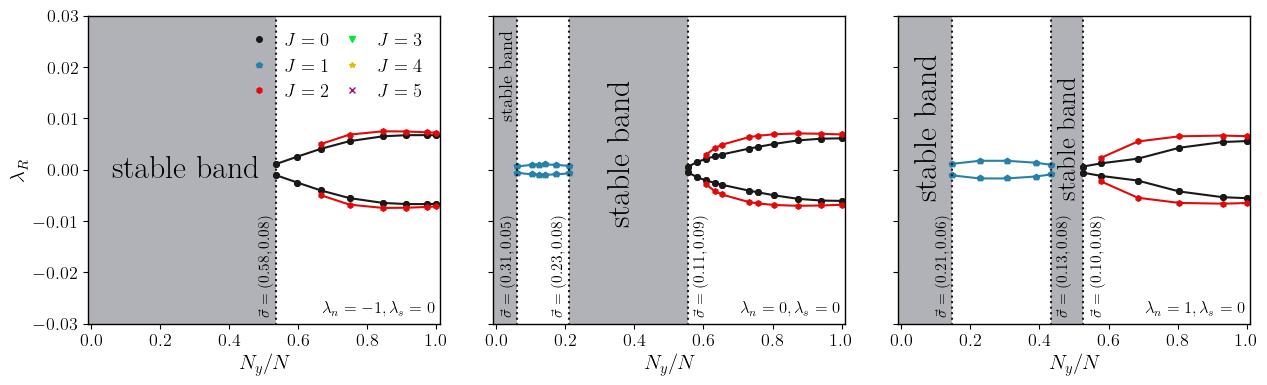

In [31]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

#######

for i in range(6):
    tempP, tempN = [], []
    for j in range(len(totalMN)):
        modos = JModesN[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        #if i == 2:
        #    print(j, datosMasaN[j][1]/totalMN[j], modos)
        ax[0].plot([(datosMasaN[j][1]/totalMN[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasaN[j][1]/totalMN[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasaN[j][1]/totalMN[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax[0].plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax[0].plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax[0].plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax[0].set_xlim(-0.01, 1.01)
    ax[0].set_ylim(-0.03, .03)
    ax[0].set_xlabel(r'$N_y/N$')    
ax[0].set_ylabel(r'$\lambda_R$')

jv = -8
xR = (datosMasaN[jv][1]/totalMN[jv])
_, _, sDnewx, _, _, _ = datasS0N[jv][0]
_, _, sDnewy, _, _, _ = datasS0N[jv][1]
ax[0].text(x=xR-0.055, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax[0].vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
ax[0].axvspan(-0.1, xR, facecolor='#656473', alpha=0.5)

ax[0].text(0.06, -0.0015, s=r'stable band', rotation='horizontal', fontsize='x-large')#, fontsize='small'
ax[0].legend(frameon=False, fontsize='small', loc='best', ncol=2, columnspacing=0.2, handletextpad=0.4)

ax[0].text(0.67, -0.028, s=r'$\lambda_n=-1, \lambda_s=0$', fontsize=12)
########################################

for i in range(6):
    tempP, tempN = [], []
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        #if i == 2:
            #print(j, datosMasa[j][1]/totalM[j], modos)
        ax[1].plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos) / scal_fact, ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasa[j][1]/totalM[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasa[j][1]/totalM[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        if i==0 or i==2:
            ind=np.argsort(tempP[:, 0])
            ax[1].plot((tempP[:, 0])[ind], (tempP[:,1])[ind] / scal_fact, ls='-', c=col[i])

            ind=np.argsort(tempN[:, 0])
            ax[1].plot((tempN[:, 0])[ind], (tempN[:,1])[ind] / scal_fact, ls='-', c=col[i])
        else:
            ax[1].plot(tempP[:, 0], tempP[:,1] / scal_fact, ls='-', c=col[i])
            ax[1].plot(tempN[:, 0], tempN[:,1] / scal_fact, ls='-', c=col[i])
    ax[1].plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax[1].set_xlim(-0.01, 1.01)
    ax[1].set_ylim(-0.03, .03)
    ax[1].set_xlabel(r'$N_y/N$')    
#ax[1].set_ylabel(r'$\lambda_R$')

jv = 18 # 15
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[1].text(x=xR-0.055, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0]/ scal_fact, sDnewy[0]/ scal_fact), fontsize=11, rotation=90)
ax[1].vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

jv = 23 # 6
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[1].text(x=xR1-0.05, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0]/ scal_fact, sDnewy[0]/ scal_fact), fontsize=11, rotation=90)
ax[1].vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

jv = 10 #9
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[1].text(x=xR12 + 0.015, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0]/ scal_fact, sDnewy[0]/ scal_fact), fontsize=11, rotation=90)
ax[1].vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

ax[1].axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax[1].axvspan(xR12, xR, facecolor='#656473', alpha=0.5)

ax[1].text(0.32, -0.01, s=r'stable band', rotation='vertical', fontsize='x-large')#, fontsize='small'
ax[1].text(0.01, 0.01, s=r'stable band', rotation='vertical', fontsize='small')
#ax[1].legend(frameon=False, fontsize='small', loc=(0.27, 0.815), ncol=2, columnspacing=0.2, handletextpad=0.4)

ax[1].text(0.705, -0.028, s=r'$\lambda_n=0, \lambda_s=0$', fontsize=12)

################################
for i in range(6):
    tempP, tempN = [], []
    for j in range(len(totalMP)):
        modos = JModesP[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        #if i == 2:
        #    print(j, datosMasaP[j][1]/totalMP[j], modos)
        ax[2].plot([(datosMasaP[j][1]/totalMP[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasaP[j][1]/totalMP[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasaP[j][1]/totalMP[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax[2].plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax[2].plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax[2].plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax[2].set_xlim(-0.01, 1.01)
    ax[2].set_ylim(-0.03, .03)
    ax[2].set_xlabel(r'$N_y/N$')    
#ax[2].set_ylabel(r'$\lambda_R$')

jv = 13
xR = (datosMasaP[jv][1]/totalMP[jv])
_, _, sDnewx, _, _, _ = datasS0P[jv][0]
_, _, sDnewy, _, _, _ = datasS0P[jv][1]
ax[2].text(x=xR+0.02, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax[2].vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

jv = 7
xR1 = (datosMasaP[jv][1]/totalMP[jv])
_, _, sDnewx, _, _, _ = datasS0P[jv][0]
_, _, sDnewy, _, _, _ = datasS0P[jv][1]
ax[2].text(x=xR1-0.05, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax[2].vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], lw=1, alpha=1, zorder=10)

jv = 11
xR12 = (datosMasaP[jv][1]/totalMP[jv])
_, _, sDnewx, _, _, _ = datasS0P[jv][0]
_, _, sDnewy, _, _, _ = datasS0P[jv][1]
ax[2].text(x=xR12 + 0.015, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax[2].vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])


ax[2].axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax[2].axvspan(xR12, xR, facecolor='#656473', alpha=0.5)


ax[2].text(0.45, -0.005, s=r'stable band', rotation='vertical', fontsize='large')#, fontsize='small'
ax[2].text(0.035, -0.005, s=r'stable band', rotation='vertical', fontsize='x-large')
#ax[2].legend(frameon=False, fontsize='small', loc=(0.71, 0.64), ncol=1, columnspacing=0.2, handletextpad=0.4)

ax[2].text(0.705, -0.028, s=r'$\lambda_n=1, \lambda_s=0$', fontsize=12)


In [32]:
fig.savefig('multifrequency_stability.pdf', format='pdf', metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )